## Laborator 6  -  Rezolvarea unor probleme de regresie prin metode de învățare automată

#### 💡 Probleme

**Clasificarea țesuturilor cancerigene**

Se consideră informații despre cancerul de sân la femei, informații extrase din ecografii mamare (detalii aici) precum:
- Tipul malformației identificate (țesut benign sau țesut malign)
- Caracteristici numerice ale nucleului celulelor din aceste țesuturi:
- raza (media distanțelor între centru si punctele de pe contur)
- textura (măsurată prin deviația standard a nivelelor de gri din imaginea asociată țesutului analizat)

Folosindu-se aceste date, să se decidă dacă țesutul dintr-o nouă ecografie (pentru care se cunosc cele 2 caracteristici numerice – raza și textura –) va fi etichetat ca fiind malign sau benign.


#### 📝 Cerinte

Specificaţi, proiectaţi, implementaţi si testati cate un algoritm de clasificare pentru problema 2 si problema 3 bazat pe regresie logistica.

Antrenati cate un clasificator pentru fiecare problema, pe care apoi sa ii utilizati pentru a stabili:

* daca o leziune (dintr-o mamografie) caracterizata printr-o textura de valoare 10 si o raza de valoare 18 este leziune maligna sau benigna


###### 🏵️ Cerinte opționale

Rezolvarea unei probleme de regresie/clasificare prin:

* folosirea validarii încrucișate
* investigarea diferitelor funcții de loss
* ce se întîmplă în cazul clasificarii binare daca se modifică pragul de decizie din 0.5 în alte valori. Cum se poate aprecia calitatea clasificatorului pentru diferite valori ale pragului?

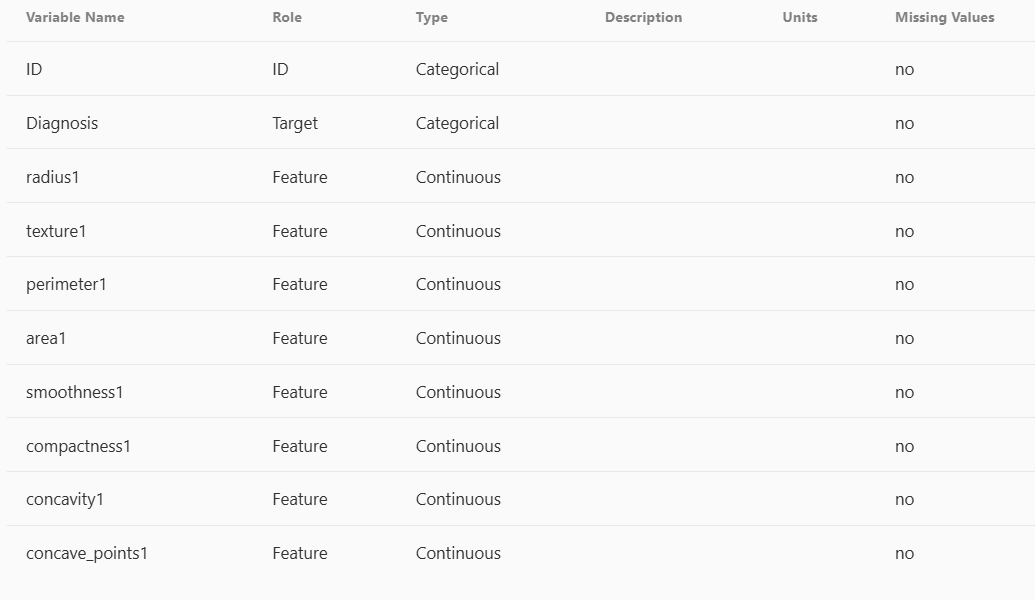

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

🔹 **Regresia logistică** este un model simplu și puternic folosit pentru **clasificare binară** (ex: da/nu, malign/benign).  
Ea combină liniar caracteristicile de intrare și transformă rezultatul într-o **probabilitate** folosind funcția sigmoid 📈.

Modelul calculează mai întâi:

$$
z = w_1 \times x_1 + w_2 \times x_2 + \dots + w_n \times x_n + b
$$

unde:
- $x_i$ sunt caracteristicile,
- $w_i$ sunt coeficienții (pantele) învățate de model,
- $b$ este bias-ul.

Apoi aplică **funcția sigmoid**:

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

care transformă $z$ într-un număr între **0** și **1** ✨ (interpretat ca probabilitate).

🔹 Dacă probabilitatea este > 0.5 ➡️ se clasifică în clasa pozitivă (ex: malign), altfel ➡️ clasa negativă (ex: benign).

In [ ]:
!pip install pandas scikit-learn

cu tool

Accuracy of the Logistic Regression model: 0.91
The lesion is predicted to be malignant.


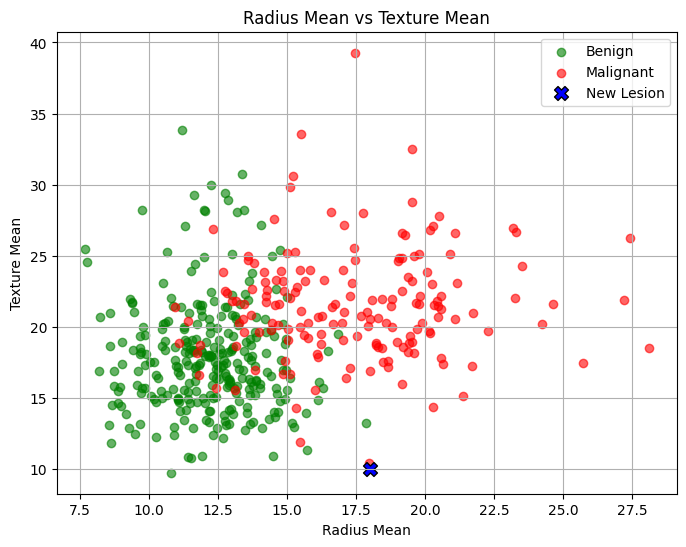

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# load and prepare data
def load_data(path):
    df = pd.read_csv(path, header=None)
    columns = ['ID', 'Diagnosis'] + [f'feature_{i}' for i in range(1, 31)]
    df.columns = columns

    df['radius_mean'] = df['feature_1']
    df['texture_mean'] = df['feature_2']

    X = df[['radius_mean', 'texture_mean']]
    y = df['Diagnosis'].map({'M': 1, 'B': 0})

    return X, y, df

# load data
X, y, df = load_data('wdbc.data')

# train the model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LogisticRegression()
model.fit(X_train, y_train)

# evaluate the model
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of the Logistic Regression model: {accuracy:.2f}")

# predict for a new lesion (texture=10, radius=18)
new_data = pd.DataFrame([[18, 10]], columns=['radius_mean', 'texture_mean'])
prediction = model.predict(new_data)

if prediction[0] == 1:
    print("The lesion is predicted to be malignant.")
else:
    print("The lesion is predicted to be benign.")

# plot the data (scatter plot) with New Lesion included
plt.figure(figsize=(8,6))

# plot benign samples
plt.scatter(
    X_train[y_train == 0]['radius_mean'],  # radius_mean for benign
    X_train[y_train == 0]['texture_mean'],  # texture_mean for benign
    color='green',
    label='Benign',
    alpha=0.6
)

# plot malignant samples
plt.scatter(
    X_train[y_train == 1]['radius_mean'],  # radius_mean for malignant
    X_train[y_train == 1]['texture_mean'],  # texture_mean for malignant
    color='red',
    label='Malignant',
    alpha=0.6
)

# highlight the new lesion
plt.scatter(
    18, 10,
    color='blue',
    label='New Lesion',
    edgecolor='black',
    s=100,
    marker='X'
)

# plot settings
plt.xlabel('Radius Mean')
plt.ylabel('Texture Mean')
plt.title('Radius Mean vs Texture Mean')
plt.legend()
plt.grid(True)
plt.show()


cod propriu

Accuracy of the Logistic Regression model: 0.63
The lesion is predicted to be malignant.


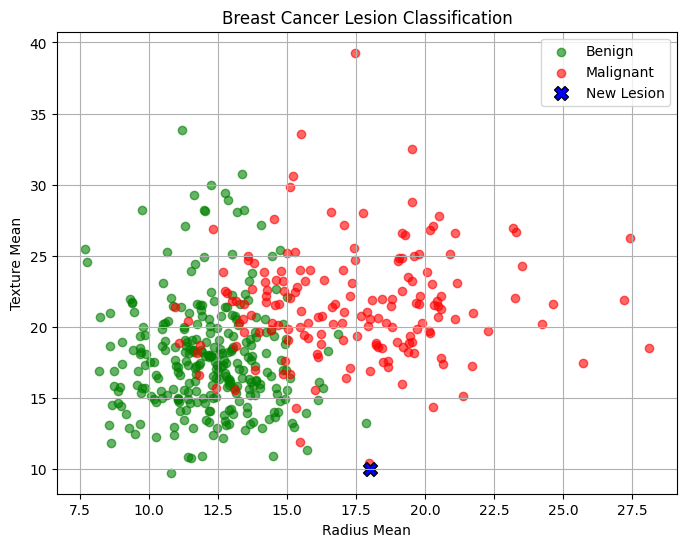

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# load and prepare data
def load_data(path):
    df = pd.read_csv(path, header=None)
    columns = ['ID', 'Diagnosis'] + [f'feature_{i}' for i in range(1, 31)]
    df.columns = columns

    df['radius_mean'] = df['feature_1']
    df['texture_mean'] = df['feature_2']

    X = df[['radius_mean', 'texture_mean']].values
    y = df['Diagnosis'].map({'M': 1, 'B': 0}).values

    return X, y, df

# load data
X, y, df = load_data('wdbc.data')

# Sigmoid function -> FORMULA
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# function to compute cost
def compute_cost(X, y, theta, epsilon=1e-5):
    m = len(y)
    h = sigmoid(X.dot(theta))
    # Add small epsilon value to avoid log(0)
    h = np.clip(h, epsilon, 1 - epsilon)  # Ensures that h is never 0 or 1
    cost = (1/m) * np.sum(-y * np.log(h) - (1 - y) * np.log(1 - h))
    return cost

# function to perform gradient descent
def gradient_descent(X, y, theta, learning_rate, iterations):
    m = len(y)
    cost_history = []

    for _ in range(iterations):
        gradient = (1/m) * X.T.dot(sigmoid(X.dot(theta)) - y)
        theta -= learning_rate * gradient
        cost_history.append(compute_cost(X, y, theta))

    return theta, cost_history

# add an intercept column to X (X_0 = 1)
X = np.c_[np.ones((X.shape[0], 1)), X]

# train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# initialize theta and train the model
theta = np.zeros(X_train.shape[1])
theta, cost_history = gradient_descent(X_train, y_train, theta, learning_rate=0.1, iterations=1000)

# evaluate the model
y_pred = sigmoid(X_test.dot(theta)) >= 0.5
accuracy = np.mean(y_pred == y_test)
print(f"Accuracy of the Logistic Regression model: {accuracy:.2f}")

# predict for a new lesion (texture=10, radius=18)
new_data = np.array([1, 18, 10])  # Add 1 for intercept term
prediction = sigmoid(new_data.dot(theta)) >= 0.5

if prediction:
    print("The lesion is predicted to be malignant.")
else:
    print("The lesion is predicted to be benign.")

# create a scatter plot of the training data
plt.figure(figsize=(8,6))

# plot benign samples
plt.scatter(
    X_train[y_train == 0][:, 1],  # radius_mean for benign
    X_train[y_train == 0][:, 2],  # texture_mean for benign
    color='green',
    label='Benign',
    alpha=0.6
)

# plot malignant samples
plt.scatter(
    X_train[y_train == 1][:, 1],  # radius_mean for malignant
    X_train[y_train == 1][:, 2],  # texture_mean for malignant
    color='red',
    label='Malignant',
    alpha=0.6
)

# highlight the new lesion
plt.scatter(
    18, 10,
    color='blue',
    label='New Lesion',
    edgecolor='black',
    s=100,
    marker='X'
)

# plot settings
plt.xlabel('Radius Mean')
plt.ylabel('Texture Mean')
plt.title('Breast Cancer Lesion Classification')
plt.legend()
plt.grid(True)
plt.show()


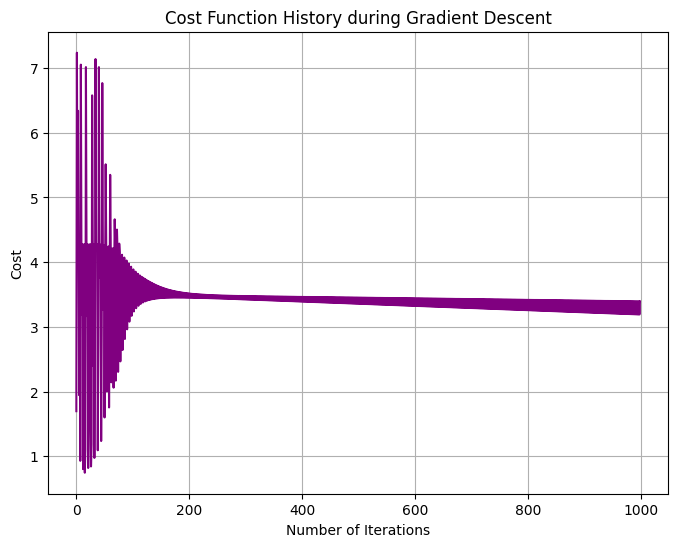

In [ ]:
# after training, plot the cost history for my code
plt.figure(figsize=(8, 6))
plt.plot(range(len(cost_history)), cost_history, color='purple')
plt.title('Cost Function History during Gradient Descent')
plt.xlabel('Number of Iterations')
plt.ylabel('Cost')
plt.grid(True)
plt.show()
